In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv("data.csv", encoding="latin1")
df.head()

,stn_code,sampling_date,state,location,agency,type,so2,no2,rspm,spm,location_monitoring_station,pm2_5,date
0,150.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",4.8,17.4,NaN,NaN,NaN,NaN,1990-02-01
1,151.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,Industrial Area,3.1,7.0,NaN,NaN,NaN,NaN,1990-02-01
2,152.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",6.2,28.5,NaN,NaN,NaN,NaN,1990-02-01
3,150.0,March - M031990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",6.3,14.7,NaN,NaN,NaN,NaN,1990-03-01
4,151.0,March - M031990,Andhra Pradesh,Hyderabad,NaN,Industrial Area,4.7,7.5,NaN,NaN,NaN,NaN,1990-03-01


In [7]:
df.columns

Index(['stn_code', 'sampling_date', 'state', 'location', 'agency', 'type',
       'so2', 'no2', 'rspm', 'spm', 'location_monitoring_station', 'pm2_5',
       'date'],
      dtype='object')

In [8]:
x = pd.to_numeric(df["no2"], errors="coerce")
x = x.dropna()
x = x.values

In [9]:
r = 102303324

ar = 0.05 * (r % 7)
br = 0.3 * ((r % 5) + 1)

print(ar, br)

0.2 1.5


In [10]:
x_scaled = x / np.max(np.abs(x))

In [11]:
z = x + ar * np.arcsin(br * x_scaled)

/tmp/ipython-input-80704445.py:1: RuntimeWarning: invalid value encountered in arcsin
  z = x + ar * np.arcsin(br * x_scaled)


In [12]:
z = z[~np.isnan(z)]

mu = np.mean(z)
var = np.var(z)
lam = 1 / (2 * var)
c = np.sqrt(lam / np.pi)

print("mu =", mu)
print("lambda =", lam)
print("c =", c)


mu = 23.00611965469464
lambda = 0.0017013858710854023
c = 0.02327161238461796


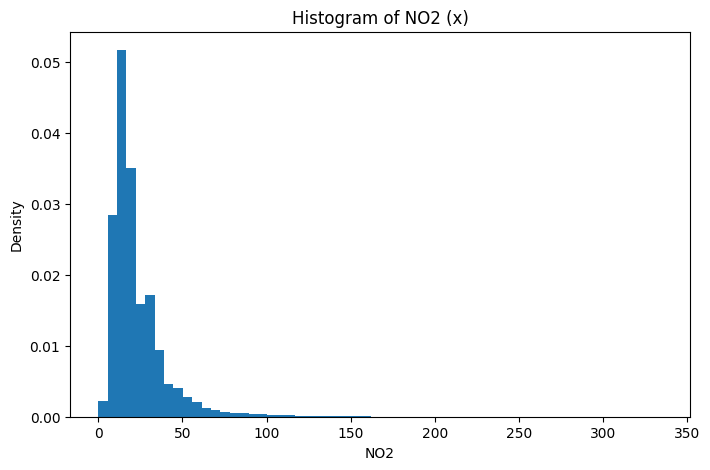

In [13]:
plt.figure(figsize=(8,5))
plt.hist(x, bins=60, density=True)
plt.title("Histogram of NO2 (x)")
plt.xlabel("NO2")
plt.ylabel("Density")
plt.show()

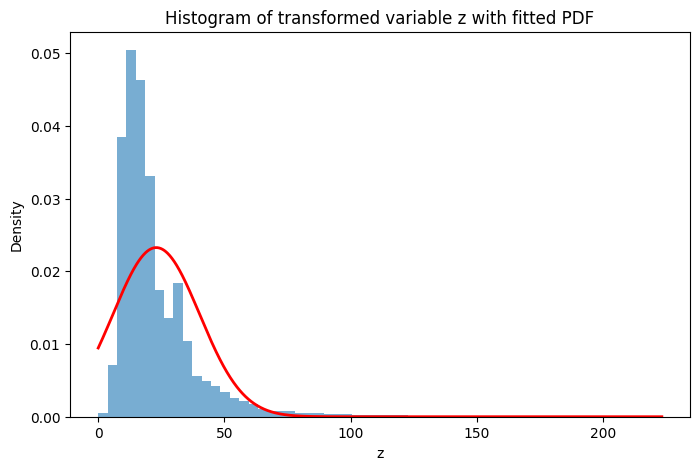

In [14]:
plt.figure(figsize=(8,5))
plt.hist(z, bins=60, density=True, alpha=0.6)
xx = np.linspace(z.min(), z.max(), 1000)
yy = c * np.exp(-lam * (xx - mu)**2)
plt.plot(xx, yy, color='red', linewidth=2)
plt.title("Histogram of transformed variable z with fitted PDF")
plt.xlabel("z")
plt.ylabel("Density")
plt.show()